# Clase 5 · Laboratorio — Pipeline completo de limpieza sobre Saber 11

**Trabajo en parejas · 90 min.**

En la pre-clase viste cada técnica aislada. En este laboratorio aplicarás el **pipeline completo** al dataset real de Saber 11:

1. Diagnóstico
2. Corrección de texto
3. Imputación de nulos
4. Tratamiento de outliers
5. Normalización
6. Encoding + Transformación logarítmica

**Checkpoint del profesor a los 50 min** (después de la Tarea 3).

Al final producirás un `df_limpio` listo para modelar.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df = pd.read_csv("saber11_muestra_500k.csv")
df_original = df.copy()  # guardar copia para comparar al final
print(f"Datos crudos: {len(df):,} filas × {df.shape[1]} columnas")

Datos crudos: 500,000 filas × 22 columnas


## Tarea 1 (15 min) — Diagnóstico completo

Antes de tocar nada, hay que saber qué hay que arreglar.

1. Calcula el **porcentaje de nulos** de cada columna. Ordénalas de mayor a menor.
2. Cuenta las **filas duplicadas** completas.
3. Para las columnas de puntaje (`PUNT_*`), reporta **min, max, media** para identificar rangos sospechosos.
4. Para 3 columnas categóricas de tu elección, muestra los valores únicos con `value_counts()` y detecta si hay inconsistencias (espacios, mayúsculas raras).

Escribe 2-3 hallazgos en una celda Markdown al final.

In [13]:
# TODO 1: porcentaje de nulos por columna (ordenado)
nulos_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Porcentaje de nulos por columna:")
print(nulos_pct.to_frame("porcentaje_nulos").round(2))

# TODO 2: duplicados
n_dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_dups:,}")

# TODO 3: estadísticos de puntajes
puntajes = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]
print("\nRango de puntajes:")
print(df[puntajes].agg(["min", "max", "mean"]).T.round(2))

# TODO 4: value_counts de 3 columnas categóricas a tu elección
columnas_categoricas = ["COLE_NATURALEZA", "COLE_JORNADA", "ESTU_GENERO"]
for columna in columnas_categoricas:
    print(f"\nValores de {columna}:")
    print(df[columna].value_counts(dropna=False))

Porcentaje de nulos por columna:
                          porcentaje_nulos
FAMI_EDUCACIONPADRE                   7.01
FAMI_TIENEINTERNET                    6.97
FAMI_EDUCACIONMADRE                   6.93
ESTU_FECHANACIMIENTO                  0.00
PERIODO                               0.00
ESTU_GENERO                           0.00
FAMI_ESTRATOVIVIENDA                  0.00
ESTU_MCPIO_RESIDE                     0.00
ESTU_DEPTO_RESIDE                     0.00
COLE_NATURALEZA                       0.00
COLE_JORNADA                          0.00
COLE_CALENDARIO                       0.00
COLE_BILINGUE                         0.00
COLE_DEPTO_UBICACION                  0.00
COLE_MCPIO_UBICACION                  0.00
PUNT_LECTURA_CRITICA                  0.00
PUNT_MATEMATICAS                      0.00
PUNT_C_NATURALES                      0.00
PUNT_SOCIALES_CIUDADANAS              0.00
PUNT_INGLES                           0.00
PUNT_GLOBAL                           0.00
DESEMP_INGLES        

**Hallazgos del diagnóstico:**
1. Se registraron datos nulos solamente en el FAMI_EDUCACIONPADRE "7.01%", FAMI_TIENEINTERNET "6.97%", FAMI_EDUCACIONMADRE "6.93%". Las demás columnas se encuentran sin nulos, es decir que el dataset ofrece una buena cantidad de información para entrenamientos y análisis.
2. Más del 70% de los colegios que participan en la prueba son de naturaleza pública y en su mayoría son estudiantes que cumplen la jornada de la mañana y tarde.
3. Los puntajes por componente tienen rango 0-100 y medias cercanas a 48.3, mientras `PUNT_GLOBAL` tiene rango 0-500 y media 248.65. Es decir que la media de los participantes de la prueba es obtener un puntaje cercano al 50% de las preguntas.

## Tarea 2 (20 min) — Corrección de texto + duplicados + imputación

1. **Corrige el texto** de todas las columnas categóricas de tipo string: `.str.strip().str.upper()`. Aplica a: COLE_NATURALEZA, COLE_JORNADA, COLE_CALENDARIO, COLE_BILINGUE, COLE_AREA_UBICACION, COLE_GENERO, FAMI_TIENEINTERNET, FAMI_TIENECOMPUTADOR, FAMI_TIENELAVADORA, FAMI_TIENEAUTOMOVIL, ESTU_GENERO.

2. **Elimina duplicados exactos** con `drop_duplicates()`. Reporta cuántas filas eliminaste.

3. **Imputa los nulos** eligiendo el método correcto:
   - Columnas numéricas continuas (PUNT_*) → mediana (son asimétricas)
   - Columnas categóricas (FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE, etc.) → moda

Justifica en Markdown por qué elegiste esos métodos.

In [14]:
# TODO 1: normalizar texto de las 11 columnas listadas
cols_texto = ["COLE_NATURALEZA","COLE_JORNADA","COLE_CALENDARIO","COLE_BILINGUE",
              "COLE_AREA_UBICACION","COLE_GENERO","FAMI_TIENEINTERNET",
              "FAMI_TIENECOMPUTADOR","FAMI_TIENELAVADORA","FAMI_TIENEAUTOMOVIL",
              "ESTU_GENERO"]
cols_texto_presentes = [col for col in cols_texto if col in df.columns]
cols_texto_ausentes = [col for col in cols_texto if col not in df.columns]
for col in cols_texto_presentes:
    df[col] = df[col].str.strip().str.upper()
if cols_texto_ausentes:
    print(f"Columnas de texto ausentes en el DataFrame: {cols_texto_ausentes}")

# TODO 2: eliminar duplicados
n_antes = len(df)
df = df.drop_duplicates()
n_eliminadas = n_antes - len(df)
print(f"Duplicados eliminados: {n_eliminadas:,}")

# TODO 3a: imputar puntajes con la mediana
puntajes = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]
nulos_puntajes = df[puntajes].isna().sum()
for col in puntajes:
    df[col] = df[col].fillna(df[col].median())
print("\nNulos imputados en puntajes:")
print(nulos_puntajes[nulos_puntajes > 0])

# TODO 3b: imputar categóricas con la moda
cols_categoricas = ["FAMI_EDUCACIONMADRE","FAMI_EDUCACIONPADRE","FAMI_ESTRATOVIVIENDA",
                    "FAMI_TIENEINTERNET","FAMI_TIENECOMPUTADOR"]
cols_categoricas_presentes = [col for col in cols_categoricas if col in df.columns]
cols_categoricas_ausentes = [col for col in cols_categoricas if col not in df.columns]
if cols_categoricas_ausentes:
    print(f"Columnas categóricas ausentes en el DataFrame: {cols_categoricas_ausentes}")
nulos_categoricas = df[cols_categoricas_presentes].isna().sum()
for col in cols_categoricas_presentes:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nNulos imputados en categóricas:")
print(nulos_categoricas[nulos_categoricas > 0])

# Validar que ya no quedan nulos en las columnas tratadas
columnas_tratadas = puntajes + cols_categoricas_presentes
nulos_restantes = df[columnas_tratadas].isna().sum().sum()
print(f"\nNulos restantes en columnas tratadas: {nulos_restantes:,}")

Columnas de texto ausentes en el DataFrame: ['COLE_AREA_UBICACION', 'COLE_GENERO', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENELAVADORA', 'FAMI_TIENEAUTOMOVIL']
Duplicados eliminados: 0

Nulos imputados en puntajes:
Series([], dtype: int64)
Columnas categóricas ausentes en el DataFrame: ['FAMI_TIENECOMPUTADOR']

Nulos imputados en categóricas:
FAMI_EDUCACIONMADRE    34662
FAMI_EDUCACIONPADRE    35072
FAMI_TIENEINTERNET     34833
dtype: int64

Nulos restantes en columnas tratadas: 0


**Justificación de los métodos elegidos:**

- Según la distribución de los datos para los puntajes PUNT_* se utilizó la mediana ya que es menos suceptible y más precisa para los valores extremos representando una mejor distribución. Si se usaba media podían quedar valores inflados afectado por los outliers.
- Para las variables categóricas se utilizó la moda porque mantiene las cateogorías y representa el valor más frecuente del grupo de datos. Las columnas categóricas solicitadas que no existen en este CSV como lo es FAMI_TIENECOMPUTADOR se reportan como ausentes y no se modifican.

## Tarea 3 (15 min) — Detección y tratamiento de outliers

1. Para PUNT_MATEMATICAS y PUNT_GLOBAL, detecta outliers con el método IQR.
2. Reporta cuántos outliers hay en cada columna.
3. Grafica un boxplot ANTES y DESPUÉS de eliminar los outliers de PUNT_MATEMATICAS.
4. **NO elimines los outliers todavía** — deja el DataFrame intacto. Solo etiquétalos.
5. Escribe en Markdown: ¿qué representan los outliers inferiores (puntajes muy bajos) en el contexto educativo colombiano? ¿Los eliminarías o los conservarías?

Outliers PUNT_MATEMATICAS: 2,935 (0.59%)
Outliers PUNT_GLOBAL:      3,315 (0.66%)


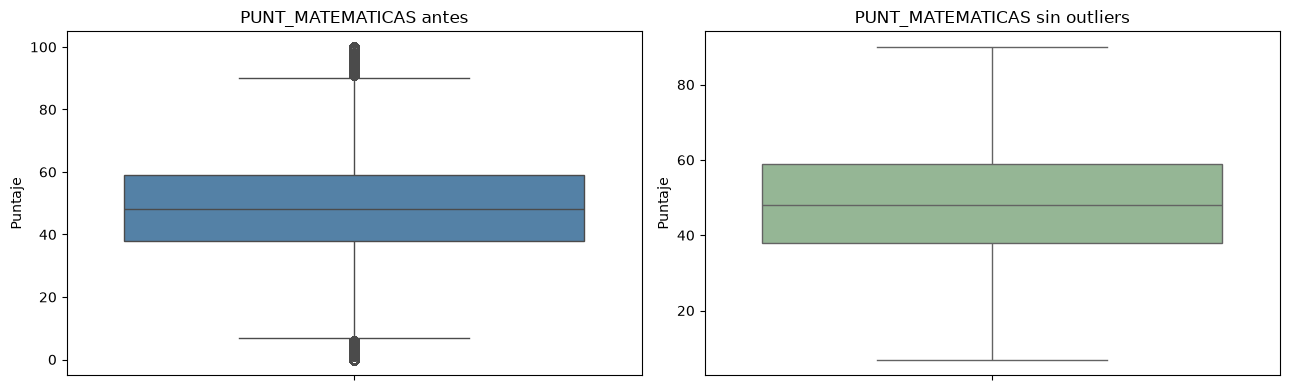

Filas conservadas en df: 500,000


In [15]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)

# TODO 1: outliers en PUNT_MATEMATICAS y PUNT_GLOBAL
out_mat = detectar_outliers_iqr(df["PUNT_MATEMATICAS"])
out_glob = detectar_outliers_iqr(df["PUNT_GLOBAL"])
print(f"Outliers PUNT_MATEMATICAS: {out_mat.sum():,} ({out_mat.mean()*100:.2f}%)")
print(f"Outliers PUNT_GLOBAL:      {out_glob.sum():,} ({out_glob.mean()*100:.2f}%)")

# TODO 2: agregar columna is_outlier (SIN eliminar) para PUNT_MATEMATICAS
df["is_outlier_matematicas"] = out_mat

# TODO 3: boxplot antes vs después usando una vista filtrada, sin modificar df
puntajes_matematicas_sin_outliers = df.loc[~out_mat, "PUNT_MATEMATICAS"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(y=df["PUNT_MATEMATICAS"], ax=axes[0], color="steelblue")
axes[0].set_title("PUNT_MATEMATICAS antes")
axes[0].set_ylabel("Puntaje")
sns.boxplot(y=puntajes_matematicas_sin_outliers, ax=axes[1], color="darkseagreen")
axes[1].set_title("PUNT_MATEMATICAS sin outliers")
axes[1].set_ylabel("Puntaje")
plt.tight_layout()
plt.show()
print(f"Filas conservadas en df: {len(df):,}")

**¿Los eliminarías o los conservarías?**

Los outliers inferiores pueden demostrar deficiencias y puntos débiles que posee el sistema educativo. Si se realiza un análisis es posible hallar evidencias de desigualdad socioneconómica, dificultad en el aprendizaje, diferencias de recursos educativos, entre otros factores. Resaltando que algunos pueden ser errores de medición o factores erróneos de estos datos.

Si conservaría estos datos, para este caso optaría por etiquetar dichos outliers y de esta forma realizar el estudio más detallado de esta información.

## ⏸ Checkpoint del profesor (10 min)

Revisamos juntos:
- ¿Cuántos duplicados eliminaste en la Tarea 2? **0**
- ¿Qué porcentaje de outliers tiene PUNT_MATEMATICAS? **2935**
- Un estudiante con puntaje = 0 en Matemáticas, ¿es outlier estadístico O es señal legítima de un problema educativo real? ** No es totalmente seguro que sea problema educativo **
- ¿Cuándo la limpieza podría HACER PERDER señal importante en los datos? ** Cuando se eliminan datos que en realidad si aportan al estudio **

## Tarea 4 (15 min) — Normalización

1. Toma los 6 puntajes (PUNT_*) del DataFrame limpio (con duplicados eliminados e imputados).
2. Aplica los **3 métodos de normalización** (MinMax, Z-score, RobustScaler) a `PUNT_MATEMATICAS`. Crea 3 columnas nuevas.
3. Grafica 4 histogramas comparativos (original + los 3 normalizados) en una figura 1×4.
4. Aplica **Z-score** a los 6 puntajes y crea el DataFrame final `df_limpio` con las columnas normalizadas.
5. Guarda `df_limpio` como parquet en `../../datos/saber11_limpio.parquet` para usarlo en clases futuras.
6. Compara `df_original` vs `df_limpio` en una tabla: filas, nulos totales, media/std de PUNT_GLOBAL.

> Al terminar esta tarea NO guardes todavía `df_limpio` — lo guardarás después de la Tarea 5 con el encoding y log ya aplicados.

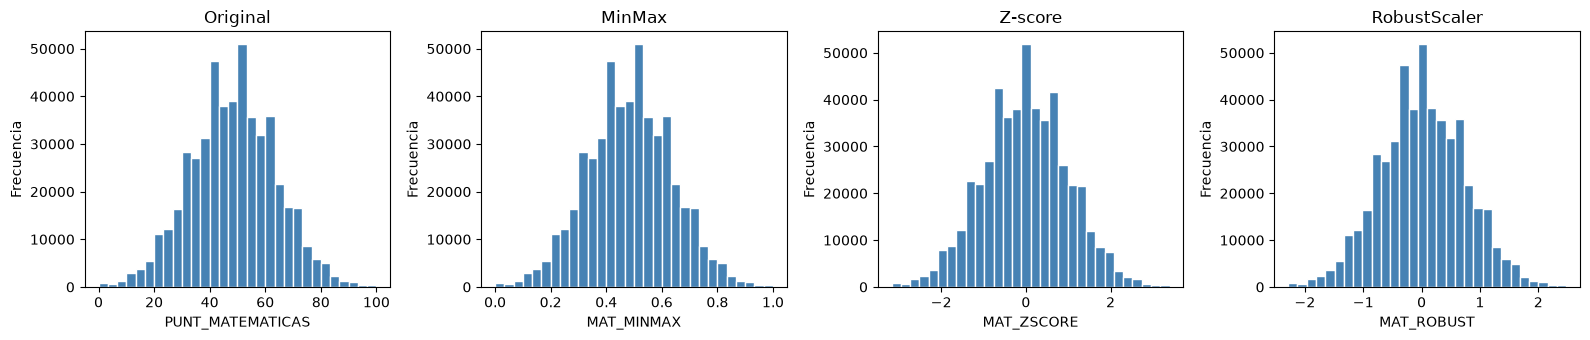

In [16]:
# TODO 1: aplicar 3 escaladores a PUNT_MATEMATICAS
serie = df[["PUNT_MATEMATICAS"]].values
df["MAT_MINMAX"] = MinMaxScaler().fit_transform(serie).ravel()
df["MAT_ZSCORE"] = StandardScaler().fit_transform(serie).ravel()
df["MAT_ROBUST"] = RobustScaler().fit_transform(serie).ravel()

# TODO 2: histograma comparativo 1x4
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
columnas_histogramas = ["PUNT_MATEMATICAS", "MAT_MINMAX", "MAT_ZSCORE", "MAT_ROBUST"]
titulos_histogramas = ["Original", "MinMax", "Z-score", "RobustScaler"]
for eje, columna, titulo in zip(axes, columnas_histogramas, titulos_histogramas):
    eje.hist(df[columna], bins=30, color="steelblue", edgecolor="white")
    eje.set_title(titulo)
    eje.set_xlabel(columna)
    eje.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [17]:
# TODO: aplicar Z-score a los 6 puntajes
puntajes = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]
scaler = StandardScaler()
df_limpio = df.copy()
df_limpio[puntajes] = scaler.fit_transform(df[puntajes])

# El guardado se realizará después de la Tarea 5, cuando se complete el encoding y el log.
print("Parquet pendiente hasta finalizar la Tarea 5.")

# TODO: comparación ORIGINAL vs LIMPIO
comparacion = pd.DataFrame({
    "Original": [len(df_original), df_original.isna().sum().sum(),
                 df_original["PUNT_GLOBAL"].mean(), df_original["PUNT_GLOBAL"].std()],
    "Limpio":   [len(df_limpio), df_limpio.isna().sum().sum(),
                 df_limpio["PUNT_GLOBAL"].mean(), df_limpio["PUNT_GLOBAL"].std()]
}, index=["Filas", "Nulos totales", "Media PUNT_GLOBAL", "Std PUNT_GLOBAL"])
print(comparacion.round(4))

Parquet pendiente hasta finalizar la Tarea 5.
                      Original    Limpio
Filas              500000.0000  500000.0
Nulos totales      104567.0000       0.0
Media PUNT_GLOBAL     248.6471      -0.0
Std PUNT_GLOBAL        53.9264       1.0


## Tarea 5 (15 min) — Encoding + Transformación logarítmica

En Machine Learning necesitas convertir texto a números y arreglar variables muy sesgadas. Este es el último paso antes de guardar `df_limpio`.

### Parte A — Encoding (8 min)

1. **Ordinal encoding** de `FAMI_ESTRATOVIVIENDA` — crea una nueva columna `ESTRATO_NUM` con el mapeo:
   `{"Sin Estrato": 0, "Estrato 1": 1, ..., "Estrato 6": 6}`

2. **One-Hot Encoding** de estas columnas nominales (usa `pd.get_dummies` con `drop_first=True`):
   `COLE_NATURALEZA`, `COLE_AREA_UBICACION`, `COLE_JORNADA`, `ESTU_GENERO`.

   Reporta cuántas columnas nuevas se generaron.

### Parte B — Transformación logarítmica (7 min)

3. Crea una nueva variable **agregada por municipio**: `estudiantes_por_mcpio = df.groupby("COLE_MCPIO_UBICACION").transform("size")`. Esa variable estará muy sesgada.

4. Aplica `np.log1p()` para crear la columna `log_estudiantes_mcpio`.

5. Grafica un histograma comparativo: original vs log-transformada. Reporta la asimetría antes y después.

In [18]:
# TODO Parte A.1: Ordinal encoding de FAMI_ESTRATOVIVIENDA
mapeo_estrato = {
    "SIN ESTRATO": 0, "0": 0,
    "ESTRATO 1": 1, "1": 1, "ESTRATO 2": 2, "2": 2,
    "ESTRATO 3": 3, "3": 3, "ESTRATO 4": 4, "4": 4,
    "ESTRATO 5": 5, "5": 5, "ESTRATO 6": 6, "6": 6
}
estrato_texto = df["FAMI_ESTRATOVIVIENDA"].astype("string").str.strip().str.upper()
df["ESTRATO_NUM"] = estrato_texto.map(mapeo_estrato).astype("Int64")

# TODO Parte A.2: One-Hot Encoding con pd.get_dummies (drop_first=True)
cols_onehot = ["COLE_NATURALEZA", "COLE_AREA_UBICACION", "COLE_JORNADA", "ESTU_GENERO"]
cols_onehot_presentes = [col for col in cols_onehot if col in df.columns]
cols_onehot_ausentes = [col for col in cols_onehot if col not in df.columns]
if cols_onehot_ausentes:
    print(f"Columnas One-Hot ausentes en el DataFrame: {cols_onehot_ausentes}")
n_cols_antes = df.shape[1]
columnas_antes_onehot = set(df.columns)
df = pd.get_dummies(df, columns=cols_onehot_presentes, drop_first=True, dtype=int)
n_cols_despues = df.shape[1]
nuevas = [c for c in df.columns if c not in columnas_antes_onehot]
print(f"Columnas antes del OneHot: {n_cols_antes}")
print(f"Columnas después del OneHot: {n_cols_despues}")
print(f"Nuevas columnas creadas: {len(nuevas)}")

# Mostrar las nuevas columnas OneHot
print("\nColumnas OneHot generadas:")
for c in nuevas:
    print(f"  {c}")

Columnas One-Hot ausentes en el DataFrame: ['COLE_AREA_UBICACION']
Columnas antes del OneHot: 27
Columnas después del OneHot: 30
Nuevas columnas creadas: 6

Columnas OneHot generadas:
  COLE_NATURALEZA_OFICIAL
  COLE_JORNADA_MAÑANA
  COLE_JORNADA_NOCHE
  COLE_JORNADA_SABATINA
  COLE_JORNADA_TARDE
  ESTU_GENERO_M


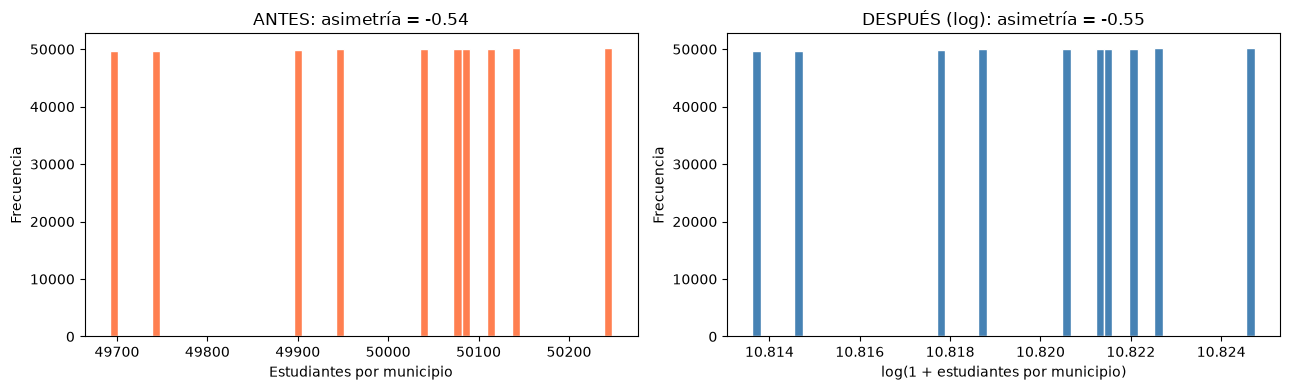


Asimetría original: -0.545
Asimetría con log:  -0.550


In [19]:
# TODO Parte B.3-4: crear estudiantes_por_mcpio y su log
df["estudiantes_por_mcpio"] = (
    df.groupby("COLE_MCPIO_UBICACION")["COLE_MCPIO_UBICACION"].transform("size")
)
df["log_estudiantes_mcpio"] = np.log1p(df["estudiantes_por_mcpio"])

# TODO Parte B.5: histograma comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ANTES
axes[0].hist(df["estudiantes_por_mcpio"], bins=60, color="coral", edgecolor="white")
axes[0].set_title(f"ANTES: asimetría = {df['estudiantes_por_mcpio'].skew():.2f}")
axes[0].set_xlabel("Estudiantes por municipio")
axes[0].set_ylabel("Frecuencia")

# DESPUÉS
axes[1].hist(df["log_estudiantes_mcpio"], bins=60, color="steelblue", edgecolor="white")
axes[1].set_title(f"DESPUÉS (log): asimetría = {df['log_estudiantes_mcpio'].skew():.2f}")
axes[1].set_xlabel("log(1 + estudiantes por municipio)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

asimetria_original = df["estudiantes_por_mcpio"].skew()
asimetria_log = df["log_estudiantes_mcpio"].skew()
print(f"\nAsimetría original: {asimetria_original:.3f}")
print(f"Asimetría con log:  {asimetria_log:.3f}")

# Actualizar el DataFrame final con encoding y transformación logarítmica.
df_limpio = df.copy()

### Reflexión Tarea 5

1. `COLE_JORNADA` generó más columnas One-Hot (`4`), porque tiene más categorías que `COLE_NATURALEZA` y `ESTU_GENERO`. La columna `COLE_AREA_UBICACION` no está disponible en este CSV.
2. La asimetría pasó de "-0.545" a "-0.550", esto significa que la varialbe está evidenciando en pocos tamaños municipales y es discreta. Para este contexto usar escala logarítmica no mejoró en una medida aceptable la asimetría
3. Para una columna categórica con 500 valores únicos evitaría One-Hot directo, porque genera más columnas y por lo tanto aumenta la dimensionalidad. Para este caso es recomendable usar otro tipo de método.

_Resultado observado:_ se generaron `6` columnas One-Hot y `df_limpio` quedó actualizado con el encoding y la transformación logarítmica.

---

## Guardado final del DataFrame limpio

Ahora sí, guarda `df_limpio` con TODO aplicado: sin duplicados, imputado, normalizado, con encoding y transformaciones.

In [20]:
# Guardar el DataFrame final
df.to_parquet("saber11_limpio.parquet", index=False)
print(f"df_limpio guardado con {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas finales:")
for c in df.columns:
    print(f"  {c}")

df_limpio guardado con 500,000 filas × 32 columnas

Columnas finales:
  PERIODO
  ESTU_FECHANACIMIENTO
  ESTU_DEPTO_RESIDE
  ESTU_MCPIO_RESIDE
  FAMI_ESTRATOVIVIENDA
  FAMI_TIENEINTERNET
  FAMI_EDUCACIONMADRE
  FAMI_EDUCACIONPADRE
  COLE_CALENDARIO
  COLE_BILINGUE
  COLE_DEPTO_UBICACION
  COLE_MCPIO_UBICACION
  PUNT_LECTURA_CRITICA
  PUNT_MATEMATICAS
  PUNT_C_NATURALES
  PUNT_SOCIALES_CIUDADANAS
  PUNT_INGLES
  PUNT_GLOBAL
  DESEMP_INGLES
  is_outlier_matematicas
  MAT_MINMAX
  MAT_ZSCORE
  MAT_ROBUST
  ESTRATO_NUM
  COLE_NATURALEZA_OFICIAL
  COLE_JORNADA_MAÑANA
  COLE_JORNADA_NOCHE
  COLE_JORNADA_SABATINA
  COLE_JORNADA_TARDE
  ESTU_GENERO_M
  estudiantes_por_mcpio
  log_estudiantes_mcpio


### Reflexión final

1. ¿Qué diferencia notaste entre el DataFrame original y el limpio?
2. ¿En qué paso del pipeline hubo mayor pérdida de datos? ¿Se justifica?
3. Si tuvieras que aplicar este mismo pipeline a tu dataset del proyecto, ¿cuál paso te preocuparía más?

_Respuesta:_ 

1. El dataframe limpio tenía datos menos compactos, donde la información se mostraba "cruda" a diferencia del dataframe limpio donde hubo información etiquetada, normalizada y más organizada, aunque resaltando que el último paso no fue el más efectivo para una mejor limpieza de datos.
2. Si se refiere a pérdida de datos como eliminación de los mismos, no existió dado que el dataset no posee duplicados cuando se quisieron eliminar, además de que los outliers se conservaron y no se optó por eliminarlos.
3. Me preocuparía más la tarea 5, dado que el "encoding + transformación" representan un paso muy importante para que el dataset contenga la información lo más optimizada y clara posible. Si se realiza una transformación con un método erróneo los pasos siguientes no serán efectivos para el estudio del dataset.

---

## Entrega

Guarda este notebook con todos los TODO completados.

**Nombre:** `02_laboratorio_apellido1_apellido2.ipynb`
**Sube a:** Moodle → Clase 5 → Laboratorio.